# ML Model Comparison — Rolling Backtest

Trains several ML models (and the project's own baselines) to predict each weather variable, using a **walk-forward backtest**: train on an expanding window of past days, predict the next day, then move the window forward one day (now including that day's real outcome) and repeat. This is the "proper backtest comparing ML vs best single provider vs simple average vs weighted average" listed as a future upgrade in the README.

Data: the 3 backfilled Open-Meteo models (`ecmwf_ifs025`, `gfs_global`, `gem_seamless`) joined against actuals — these are the only sources with enough paired history to backtest meaningfully. Roughly the first 2 months seed the earliest test day's training window; the final ~1 month is walked forward day by day as the evaluation period.

Select the **Weather Ensemble (.venv)** kernel before running. The main backtest cell retrains every model at every step, so it takes roughly 2 minutes.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, TweedieRegressor
from sklearn.pipeline import Pipeline

from weather_ensemble.config import OPEN_METEO_BACKFILL_MODELS, get_default_location
from weather_ensemble.ml import _build_wide_feature_table
from weather_ensemble.service import load_modelling_table

DB_PATH = Path("../data/weather.db") if Path("../data/weather.db").exists() else Path("data/weather.db")
LOCATION = get_default_location()
SOURCES = [f"open_meteo_{model}" for model in OPEN_METEO_BACKFILL_MODELS]

print(f"Location: {LOCATION.name}")
print(f"Sources used: {SOURCES}")

Location: Melbourne
Sources used: ['open_meteo_ecmwf_ifs025', 'open_meteo_gfs_global', 'open_meteo_gem_seamless']


## Load the 3 backfilled sources + actuals, build the wide feature table

Only rows from `SOURCES` are kept before pivoting, so the source-agreement stats (mean/std/etc.) reflect exactly these 3 models — not any live-only source that might also be sitting in the database.

In [2]:
long_df = load_modelling_table(DB_PATH, LOCATION)
long_df = long_df[long_df["source"].isin(SOURCES)]

wide_df = _build_wide_feature_table(long_df, include_targets=True)
wide_df = wide_df.sort_values("forecast_date").reset_index(drop=True)

print(f"{len(wide_df)} days available, {wide_df['forecast_date'].min().date()} to {wide_df['forecast_date'].max().date()}")
wide_df.head()

130 days available, 2026-03-15 to 2026-07-22


C:\Users\zephyr.howson\Desktop\weather-ensemble-forecaster\src\weather_ensemble\ml.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wide[f"source_std__{var}"] = wide[source_cols].std(axis=1, ddof=0)
C:\Users\zephyr.howson\Desktop\weather-ensemble-forecaster\src\weather_ensemble\ml.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wide[f"source_min__{var}"] = wide[source_cols].min(axis=1)
C:\Users\zephyr.howson\Desktop\weather-ensemble-forecaster\src\weather_ensemble\ml.py:125: PerformanceWarning: DataFrame is highly fra

,location_name,forecast_date,actual_max_temp,actual_min_temp,actual_precipitation_sum,actual_did_rain,actual_wind_speed,actual_wind_gusts,actual_cloud_cover,actual_humidity,...,source_max__pressure_msl,source_range__pressure_msl,source_count__pressure_msl,source_mean__weather_code,source_median__weather_code,source_std__weather_code,source_min__weather_code,source_max__weather_code,source_range__weather_code,source_count__weather_code
0,Melbourne,2026-03-15,27.1,10.9,0.0,0,10.9,28.8,71.417,74.375,...,1020.875,0.308,3,2.666667,3.0,0.471405,2.0,3.0,1.0,3
1,Melbourne,2026-03-16,19.4,15.9,9.9,1,11.1,27.7,99.458,88.000,...,1015.629,0.662,3,67.333333,61.0,8.956686,61.0,80.0,19.0,3
2,Melbourne,2026-03-17,19.3,15.1,1.5,1,13.2,33.1,72.125,86.375,...,1018.092,0.500,3,55.666667,53.0,5.249339,51.0,63.0,12.0,3
3,Melbourne,2026-03-18,20.5,12.7,0.0,0,10.8,28.4,57.333,85.208,...,1020.633,0.520,3,19.000000,3.0,22.627417,3.0,51.0,48.0,3
4,Melbourne,2026-03-19,19.2,14.9,1.6,1,14.1,35.3,85.042,84.917,...,1019.938,0.451,3,51.000000,51.0,0.000000,51.0,51.0,0.0,3


### Actual-data coverage check

A target with zero non-null actuals can't be backtested at all — it'll be silently skipped further down, so surface that here instead of leaving it unexplained.

In [3]:
from weather_ensemble.config import TARGETS

print(f"Non-null actual coverage per target (out of {len(wide_df)} days):")
for target in TARGETS:
    col = f"actual_{target}"
    count = int(wide_df[col].notna().sum()) if col in wide_df.columns else 0
    flag = "  <-- no observed data; will be skipped in the backtest below" if count == 0 else ""
    print(f"  {target:20s} {count:3d}{flag}")

Non-null actual coverage per target (out of 130 days):
  max_temp             130
  min_temp             130
  precipitation_sum    130
  did_rain             130
  wind_speed           130
  wind_gusts           130
  cloud_cover          130
  humidity             130
  pressure_msl         130


In [4]:
CONTINUOUS_TARGETS = ["max_temp", "min_temp", "precipitation_sum", "wind_speed", "wind_gusts", "cloud_cover", "humidity", "pressure_msl"]
# uv_index was removed from the project entirely (forecast vs actual measured
# different things - see ml.py/README) so it's dropped from this list too;
# cloud_cover/humidity/pressure_msl are added since those are now also
# modelled in production (ml.py's TARGET_MAP) and belong in a comparison
# that covers "every metric".

## Distribution of each target's actual values

Before picking model candidates, look at the *shape* of what's being predicted. A model family's
assumptions (Gaussian residuals, constant variance, no point mass at a boundary) should match the
target's actual distribution - guessing at this instead of checking it is exactly what led to a
bad outcome in production (see `ml.py`'s `CEILING_TARGETS` comment: a log-transform for
`precipitation_sum` was implemented on the assumption it would help a skewed distribution, shipped,
and only then found - empirically, via a real backtest - to make things worse).

variable                 n     mean      std    skew  kurtosis  zero_frac
max_temp               130    18.04     4.34    0.73     -0.25       0.00
min_temp               130    10.41     3.36   -0.08     -0.34       0.00
precipitation_sum      130     2.31     4.61    3.02     11.14       0.46
wind_speed             130    15.49     6.70    0.45     -0.76       0.00
wind_gusts             130    37.13    15.15    0.43     -0.68       0.00
cloud_cover            130    62.39    22.50   -0.61     -0.21       0.00
humidity               130    77.01    10.83   -0.80      0.44       0.00
pressure_msl           130  1021.49     8.51   -0.53      0.30       0.00


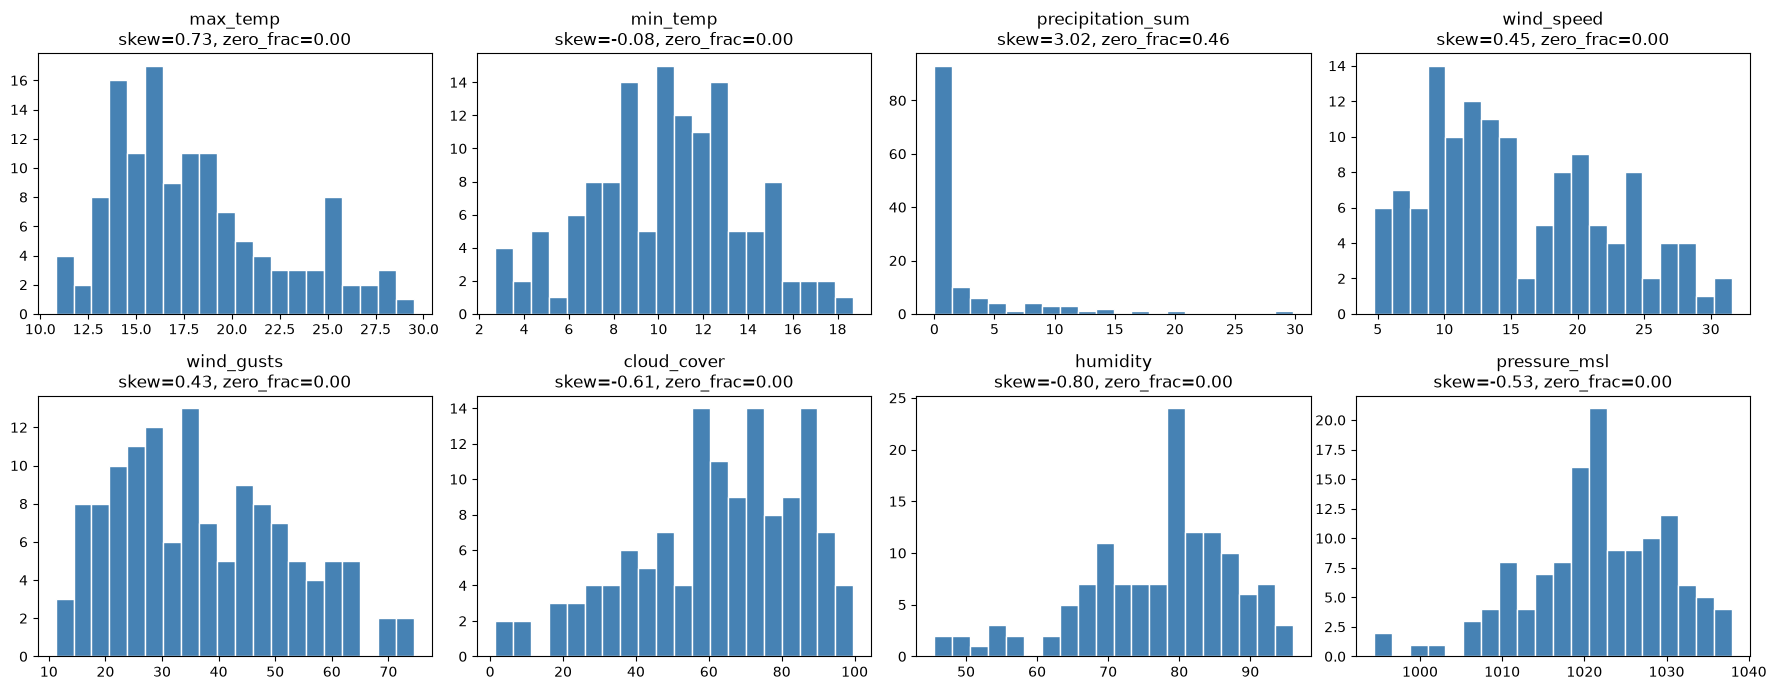

In [5]:
import matplotlib.pyplot as plt
from scipy import stats

print(f"{'variable':20s} {'n':>5s} {'mean':>8s} {'std':>8s} {'skew':>7s} {'kurtosis':>9s} {'zero_frac':>10s}")
dist_rows = []
for var in CONTINUOUS_TARGETS:
    col = f"actual_{var}"
    s = wide_df[col].dropna()
    if s.empty:
        print(f"{var:20s}  <-- no observed data")
        continue
    zero_frac = float((s == 0).mean())
    dist_rows.append({
        "variable": var, "n": len(s), "mean": s.mean(), "std": s.std(),
        "skew": stats.skew(s), "kurtosis": stats.kurtosis(s), "zero_frac": zero_frac,
    })
    print(f"{var:20s} {len(s):5d} {s.mean():8.2f} {s.std():8.2f} {stats.skew(s):7.2f} {stats.kurtosis(s):9.2f} {zero_frac:10.2f}")

dist_stats = pd.DataFrame(dist_rows).set_index("variable")

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, var in zip(axes.flat, CONTINUOUS_TARGETS):
    s = wide_df[f"actual_{var}"].dropna()
    if s.empty:
        ax.axis("off")
        continue
    ax.hist(s, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(f"{var}\nskew={stats.skew(s):.2f}, zero_frac={(s == 0).mean():.2f}")
for ax in axes.flat[len(CONTINUOUS_TARGETS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### What the distributions say about model choice

- **max_temp** (skew ≈ 0.7), **min_temp** (skew ≈ -0.1), **wind_speed** (skew ≈ 0.5),
  **wind_gusts** (skew ≈ 0.4), **cloud_cover** (skew ≈ -0.6), **humidity** (skew ≈ -0.8),
  **pressure_msl** (skew ≈ -0.5): all close to symmetric, no zero-inflation, kurtosis near 0
  (no heavy tails). A linear model's Gaussian-residual assumption is a reasonable match for all
  seven of these - nothing here motivates a different model family.
- **precipitation_sum** is the outlier: skew ≈ 3.0, kurtosis ≈ 11 (heavy-tailed), and ~45% of
  days are *exactly* zero. That's a classic zero-inflated, right-skewed shape (a "compound
  Poisson-Gamma" in GLM terms) - nothing like the other seven targets, and not what a plain
  Ridge/Linear fit on raw mm assumes. Two distribution-appropriate alternatives are added below,
  for `precipitation_sum` only:
  1. **`TweedieRegressor`** (power between 1 and 2, log link) - a GLM built specifically for
     "many zeros, right-skewed positive remainder" data. Unlike the log1p/expm1 wrapper tried in
     production (which fits an ordinary least-squares Ridge in log-space, then exponentiates -
     so any moderate overshoot in log-space explodes on inversion), Tweedie fits directly against
     its own deviance in the log link, so it doesn't inherit that same failure mode.
  2. **Hurdle model** - classify rain/no-rain first (the `did_rain` classifier below already gets
     ~87% accuracy), then only fit the amount regressor on wet-day rows. This stops one regressor
     from having to compromise between "predict exactly 0" and "predict a large number on the
     rare heavy-rain day" in a single fit.

  Both are evaluated in the same walk-forward backtest below, empirically, rather than assumed to
  help - the production incident is a reminder that this needs checking, not guessing.

## Train/test split — ~2 months initial train, ~1 month rolling test

In [6]:
TRAIN_FRACTION = 2 / 3  # ~2 months of a ~3-month dataset

train_size = int(round(len(wide_df) * TRAIN_FRACTION))
test_size = len(wide_df) - train_size

print(f"Initial training window: {train_size} days "
      f"({wide_df['forecast_date'].iloc[0].date()} to {wide_df['forecast_date'].iloc[train_size - 1].date()})")
print(f"Rolling test window: {test_size} days "
      f"({wide_df['forecast_date'].iloc[train_size].date()} to {wide_df['forecast_date'].iloc[-1].date()})")

Initial training window: 87 days (2026-03-15 to 2026-06-09)
Rolling test window: 43 days (2026-06-10 to 2026-07-22)


## Candidates

- **Baselines** mirror what's already in production (`service.py`): `simple_average` (unweighted mean across the 3 sources), `best_single_source` (whichever source had the lowest MAE on the training window so far), and `mae_weighted_average` (the same inverse-MAE weighting `blend_forecast` uses today).
- **ML models**: Linear Regression, Ridge, Random Forest, Gradient Boosting, Hist Gradient Boosting — each retrained from scratch at every step on all data available up to that point.
- **Distribution-informed additions for `precipitation_sum` only** (see the distribution analysis above): `tweedie` (a GLM suited to zero-inflated, right-skewed positive data), `hurdle_ridge` (classify rain/no-rain, then regress amount only on wet days), and `soft_hurdle_ridge` (same two stages, but blended by P(rain) instead of a hard 0/1 cutoff). None of the three are added for the other seven targets, since none of those showed the zero-inflation/heavy-skew shape that motivates them.

In [7]:
def compute_source_maes(train_df: pd.DataFrame, var: str) -> dict:
    """Per-source MAE for `var`, computed only from the training window (no lookahead)."""
    actual_col = f"actual_{var}"
    maes = {}
    for source in SOURCES:
        col = f"{source}__{var}"
        if col not in train_df or actual_col not in train_df:
            continue
        pair = train_df[[col, actual_col]].dropna()
        if not pair.empty:
            maes[source] = (pair[col] - pair[actual_col]).abs().mean()
    return maes


def baseline_predictions(test_row: pd.DataFrame, var: str, maes: dict) -> dict:
    """simple_average / best_single_source / mae_weighted_average for one test day."""
    preds = {}

    mean_col = f"source_mean__{var}"
    if mean_col in test_row and pd.notna(test_row[mean_col].iloc[0]):
        preds["simple_average"] = float(test_row[mean_col].iloc[0])

    available = {s: test_row[f"{s}__{var}"].iloc[0] for s in SOURCES if f"{s}__{var}" in test_row}
    available = {s: v for s, v in available.items() if pd.notna(v)}
    if not available:
        return preds

    if maes:
        ranked = sorted(maes, key=maes.get)
        best_source = next((s for s in ranked if s in available), None)
        if best_source:
            preds["best_single_source"] = float(available[best_source])

        weighted_sum, total_weight = 0.0, 0.0
        for source, value in available.items():
            mae = maes.get(source)
            weight = 1.0 / mae if mae and mae > 0 else 1.0
            weighted_sum += value * weight
            total_weight += weight
        preds["mae_weighted_average"] = weighted_sum / total_weight
    else:
        preds["best_single_source"] = float(next(iter(available.values())))
        preds["mae_weighted_average"] = float(np.mean(list(available.values())))

    return preds

### Feature set — narrowed per target to curb overfitting

Using all ~111 engineered columns (every forecast variable's per-source values and cross-source stats) as
features for every target — against only ~60 training rows at the start of the test window — is a classic
`p >> n` setup, and it showed: Linear Regression in particular overfit badly.

Fixed by restricting each target's features to just its own variable: the 3 raw per-source forecasts, the
cross-source mean/median/std/min/max/range for that variable, and 3 date features (month, day-of-year,
day-of-week). That's ~12 features per target instead of 111 — comfortably below the training window size.
`source_count` is dropped entirely since all 3 sources are always present in this backfilled dataset
(constant value, zero information). The tree-based models also get explicit depth/subsample limits as a
second line of defense against overfitting on a still-small dataset.

In [8]:
DATE_FEATURES = ["month", "day_of_year", "day_of_week"]


def features_for_target(var: str) -> list:
    """Only this variable's own signals - its 3 per-source forecasts, cross-source stats, and date features."""
    cols = [f"{source}__{var}" for source in SOURCES]
    cols += [f"source_{stat}__{var}" for stat in ["mean", "median", "std", "min", "max", "range"]]
    cols = [c for c in cols if c in wide_df.columns]
    return cols + DATE_FEATURES


def make_regressors(var: str | None = None) -> dict:
    """Fresh, unfitted pipelines — called once per (test day, variable) so no state leaks across fits.

    `var` lets a target's distribution shape (see the analysis above) add its own extra candidates
    instead of every target getting the same fixed model list regardless of whether it fits.
    """
    regressors = {
        "linear_regression": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", LinearRegression())]),
        "ridge": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", Ridge(alpha=1.0))]),
        "random_forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=200, max_depth=6, min_samples_leaf=3, random_state=42, n_jobs=-1,
            )),
        ]),
        "gradient_boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingRegressor(n_estimators=100, max_depth=3, subsample=0.8, random_state=42)),
        ]),
        "hist_gradient_boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingRegressor(max_depth=4, l2_regularization=1.0, random_state=42)),
        ]),
    }

    if var == "precipitation_sum":
        # power=1.5 -> compound Poisson-Gamma: the standard Tweedie choice for data that is
        # exactly zero part of the time and right-skewed continuous the rest of the time - see
        # the distribution analysis above. log link fits the linear predictor in log-space like
        # the abandoned log1p/expm1 wrapper did, but Tweedie optimises its own deviance directly
        # against that link rather than plain squared-error, so it doesn't inherit the same
        # overshoot-then-explode failure mode on inversion.
        regressors["tweedie"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", TweedieRegressor(power=1.5, link="log", alpha=1.0, max_iter=1000)),
        ])

    return regressors


print("Feature count per target:")
for var in CONTINUOUS_TARGETS:
    print(f"  {var:20s} {len(features_for_target(var))} features")

Feature count per target:
  max_temp             12 features
  min_temp             12 features
  precipitation_sum    12 features
  wind_speed           12 features
  wind_gusts           12 features
  cloud_cover          12 features
  humidity             12 features
  pressure_msl         12 features


## Run the walk-forward backtest

Retrains every model at every step — takes roughly 2 minutes.

### Aside: "two different models for wet vs. dry days" - isn't that the hurdle model?

Yes - `hurdle_ridge` below already is that: stage 1 (logistic regression) decides wet/dry, stage 2
(Ridge) is fit *only on wet-day rows* and supplies the amount. "Dry" isn't a second fitted model,
though - it's just a hard-coded constant 0. That hard 0/1 cutoff is exactly where it can lose to
the baseline: a day the classifier calls "dry" with 51% confidence gets predicted as exactly 0,
even though the wet-day regressor might have a perfectly reasonable amount estimate sitting right
there unused. `soft_hurdle_ridge` below fixes that by blending instead of cutting: predicted
amount = P(rain) × wet-day regressor's estimate, so a low-confidence call lands close to a small
fraction of the wet estimate rather than snapping to either extreme.

In [9]:
def hurdle_prediction(train_df: pd.DataFrame, test_row: pd.DataFrame, features: list) -> float | None:
    """Two-stage precipitation_sum prediction: classify rain/no-rain, then regress the amount
    using only wet-day training rows. Precipitation is ~45% exact zeros (see the distribution
    analysis above) - asking one regressor to fit "mostly 0, sometimes large" in a single pass
    is exactly the mismatch a hurdle model is designed to avoid. Returns None (skip this
    candidate for this day) if there isn't enough training data yet to fit both stages.
    """
    rain_col, amount_col = "actual_did_rain", "actual_precipitation_sum"
    clf_train = train_df[features + [rain_col]].dropna(subset=[rain_col])
    if len(clf_train) < 10 or clf_train[rain_col].nunique() < 2:
        return None

    classifier = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", LogisticRegression(max_iter=1000))])
    classifier.fit(clf_train[features], clf_train[rain_col])
    X_test = test_row.reindex(columns=features)
    predicted_rain = int(classifier.predict(X_test)[0])
    if predicted_rain == 0:
        return 0.0

    wet_train = train_df[train_df[amount_col] > 0][features + [amount_col]].dropna(subset=[amount_col])
    if len(wet_train) < 5:
        return None

    amount_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", Ridge(alpha=1.0))])
    amount_model.fit(wet_train[features], wet_train[amount_col])
    return max(0.0, float(amount_model.predict(X_test)[0]))


def soft_hurdle_prediction(train_df: pd.DataFrame, test_row: pd.DataFrame, features: list) -> float | None:
    """Same two-stage idea as hurdle_prediction, but blends smoothly instead of hard-cutting at
    the classifier's 0/1 boundary: predicted amount = P(rain) x the wet-day regressor's estimate.
    A wrong hard classification on hurdle_ridge costs the whole prediction (0 on a day that was
    actually wet, or the full wet-day estimate on a day that was actually dry) - weighting by
    probability instead lets a low-confidence day land close to a small fraction of the wet-day
    estimate rather than snapping to either extreme.
    """
    rain_col, amount_col = "actual_did_rain", "actual_precipitation_sum"
    clf_train = train_df[features + [rain_col]].dropna(subset=[rain_col])
    if len(clf_train) < 10 or clf_train[rain_col].nunique() < 2:
        return None

    classifier = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", LogisticRegression(max_iter=1000))])
    classifier.fit(clf_train[features], clf_train[rain_col])
    X_test = test_row.reindex(columns=features)
    # classes_ is sorted ascending ([0, 1]) for a 0/1 target, so column 1 is P(rain).
    rain_probability = float(classifier.predict_proba(X_test)[0][1])

    wet_train = train_df[train_df[amount_col] > 0][features + [amount_col]].dropna(subset=[amount_col])
    if len(wet_train) < 5:
        return None

    amount_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", Ridge(alpha=1.0))])
    amount_model.fit(wet_train[features], wet_train[amount_col])
    wet_amount = max(0.0, float(amount_model.predict(X_test)[0]))
    return rain_probability * wet_amount

In [10]:
records = []

for i in range(train_size, len(wide_df)):
    train_df = wide_df.iloc[:i]
    test_row = wide_df.iloc[[i]]
    test_date = test_row["forecast_date"].iloc[0]

    for var in CONTINUOUS_TARGETS:
        actual_col = f"actual_{var}"
        if actual_col not in wide_df.columns or pd.isna(test_row[actual_col].iloc[0]):
            continue
        actual_value = float(test_row[actual_col].iloc[0])

        maes = compute_source_maes(train_df, var)
        candidates = baseline_predictions(test_row, var, maes)

        features = features_for_target(var)
        train = train_df[features + [actual_col]].dropna(subset=[actual_col])
        if len(train) >= 10:
            X_train, y_train = train[features], train[actual_col]
            X_test = test_row.reindex(columns=features)
            for name, model in make_regressors(var).items():
                model.fit(X_train, y_train)
                candidates[name] = float(model.predict(X_test)[0])

        if var == "precipitation_sum":
            hurdle = hurdle_prediction(train_df, test_row, features)
            if hurdle is not None:
                candidates["hurdle_ridge"] = hurdle
            soft_hurdle = soft_hurdle_prediction(train_df, test_row, features)
            if soft_hurdle is not None:
                candidates["soft_hurdle_ridge"] = soft_hurdle

        for candidate, prediction in candidates.items():
            if prediction is None or (isinstance(prediction, float) and np.isnan(prediction)):
                continue
            records.append({
                "forecast_date": test_date,
                "variable": var,
                "candidate": candidate,
                "prediction": prediction,
                "actual": actual_value,
                "abs_error": abs(prediction - actual_value),
            })

    done = i - train_size + 1
    if done % 5 == 0 or done == test_size:
        print(f"  ...evaluated {done}/{test_size} test days")

results_df = pd.DataFrame(records)
print(f"\n{len(results_df)} (day, variable, candidate) predictions scored")

  ...evaluated 5/43 test days


  ...evaluated 10/43 test days


  ...evaluated 15/43 test days


  ...evaluated 20/43 test days


  ...evaluated 25/43 test days


  ...evaluated 30/43 test days


  ...evaluated 35/43 test days


  ...evaluated 40/43 test days


  ...evaluated 43/43 test days

2881 (day, variable, candidate) predictions scored


## Results — MAE per candidate per variable

Lower is better.

In [11]:
summary = results_df.groupby(["variable", "candidate"])["abs_error"].mean().unstack("candidate").round(3)
summary

candidate,best_single_source,gradient_boosting,hist_gradient_boosting,hurdle_ridge,linear_regression,mae_weighted_average,random_forest,ridge,simple_average,soft_hurdle_ridge,tweedie
variable,,,,,,,,,,,
cloud_cover,4.833,5.396,6.583,NaN,4.819,5.719,5.017,4.822,9.038,NaN,NaN
humidity,1.503,1.643,2.264,NaN,1.448,2.576,1.671,1.446,3.845,NaN,NaN
max_temp,0.421,0.505,0.846,NaN,0.469,0.503,0.517,0.441,0.569,NaN,NaN
min_temp,0.398,0.336,0.740,NaN,0.282,0.317,0.446,0.285,0.394,NaN,NaN
precipitation_sum,0.998,1.152,1.240,0.91,1.084,0.868,1.065,1.094,0.897,0.914,1.559
pressure_msl,0.108,0.439,2.352,NaN,0.085,0.132,0.757,0.098,0.174,NaN,NaN
wind_gusts,2.751,3.027,3.883,NaN,2.143,2.852,3.218,2.169,3.527,NaN,NaN
wind_speed,1.453,1.229,1.426,NaN,1.035,1.222,1.082,0.964,1.301,NaN,NaN


## Overall ranking

Raw MAE isn't comparable across variables on different scales (°C vs km/h vs mm), so rank candidates within each variable, then average the ranks — a rank of 1 means "best on average across all variables."

`tweedie` and `hurdle_ridge` only produced predictions for `precipitation_sum`, so they're excluded from this cross-variable ranking - averaging their single precipitation_sum rank against every other candidate's 8-variable average would flatter them for having fewer variables to be mediocre on, not for being genuinely better. They're compared fairly in the `precipitation_sum`-only ranking below instead.

In [12]:
PRECIP_ONLY_CANDIDATES = ["tweedie", "hurdle_ridge", "soft_hurdle_ridge"]
cross_variable_summary = summary.drop(columns=[c for c in PRECIP_ONLY_CANDIDATES if c in summary.columns])

ranks = cross_variable_summary.rank(axis=1)
overall_rank = ranks.mean(axis=0).sort_values()
print("Average rank across all variables (lower is better), excluding precipitation_sum-only candidates:")
print(overall_rank)

print("\nprecipitation_sum candidates ranked against each other (lower MAE is better):")
summary.loc["precipitation_sum"].dropna().sort_values()

Average rank across all variables (lower is better), excluding precipitation_sum-only candidates:
candidate
linear_regression         2.000
ridge                     2.250
best_single_source        3.750
mae_weighted_average      4.125
gradient_boosting         5.125
random_forest             5.250
simple_average            6.000
hist_gradient_boosting    7.500
dtype: float64

precipitation_sum candidates ranked against each other (lower MAE is better):


candidate
mae_weighted_average      0.868
simple_average            0.897
hurdle_ridge              0.910
soft_hurdle_ridge         0.914
best_single_source        0.998
random_forest             1.065
linear_regression         1.084
ridge                     1.094
gradient_boosting         1.152
hist_gradient_boosting    1.240
tweedie                   1.559
Name: precipitation_sum, dtype: float64

In [13]:
best = overall_rank.index[0]
print(f"Best-performing candidate over this backtest: '{best}'\n")

if "mae_weighted_average" in summary.columns and best != "mae_weighted_average":
    print("How it compares to the project's current production baseline ('mae_weighted_average'):")
    display(summary[[best, "mae_weighted_average"]])
else:
    display(summary[[best]])

Best-performing candidate over this backtest: 'linear_regression'

How it compares to the project's current production baseline ('mae_weighted_average'):


candidate,linear_regression,mae_weighted_average
variable,,
cloud_cover,4.819,5.719
humidity,1.448,2.576
max_temp,0.469,0.503
min_temp,0.282,0.317
precipitation_sum,1.084,0.868
pressure_msl,0.085,0.132
wind_gusts,2.143,2.852
wind_speed,1.035,1.222


## Bonus: does it rain? (classification)

`did_rain` is binary, so it needs classifiers rather than regressors. Compared here: a majority-class baseline, logistic regression, and a random forest classifier — all restricted to `features_for_target("precipitation_sum")` since rain is fundamentally a precipitation question, not a humidity/pressure/wind one.

In [14]:
def make_classifiers() -> dict:
    return {
        "logistic_regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")), ("model", LogisticRegression(max_iter=1000)),
        ]),
        "random_forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=3, random_state=42, n_jobs=-1)),
        ]),
    }


clf_features = features_for_target("precipitation_sum")
clf_records = []
actual_col = "actual_did_rain"

for i in range(train_size, len(wide_df)):
    train_df = wide_df.iloc[:i]
    test_row = wide_df.iloc[[i]]
    test_date = test_row["forecast_date"].iloc[0]

    if actual_col not in wide_df.columns or pd.isna(test_row[actual_col].iloc[0]):
        continue
    actual_value = int(test_row[actual_col].iloc[0])

    train = train_df[clf_features + [actual_col]].dropna(subset=[actual_col])
    if len(train) < 10 or train[actual_col].nunique() < 2:
        continue

    X_train, y_train = train[clf_features], train[actual_col]
    X_test = test_row.reindex(columns=clf_features)

    predictions = {"majority_class": int(y_train.mode().iloc[0])}
    for name, model in make_classifiers().items():
        model.fit(X_train, y_train)
        predictions[name] = int(model.predict(X_test)[0])

    for candidate, prediction in predictions.items():
        clf_records.append({
            "forecast_date": test_date,
            "candidate": candidate,
            "prediction": prediction,
            "actual": actual_value,
            "correct": prediction == actual_value,
        })

clf_results_df = pd.DataFrame(clf_records)
print(f"{clf_results_df['forecast_date'].nunique()} test days scored for did_rain\n")
clf_results_df.groupby("candidate")["correct"].mean().sort_values(ascending=False).rename("accuracy")

43 test days scored for did_rain



candidate
random_forest          0.930233
logistic_regression    0.906977
majority_class         0.418605
Name: accuracy, dtype: float64

## Your own experiments

Adjust `TRAIN_FRACTION`, `CONTINUOUS_TARGETS`, `features_for_target()`, or the model dicts in `make_regressors()` / `make_classifiers()` above and re-run the backtest cells to explore further.